Claude version

构造模拟数据...
数据维度:
  A_true: (81, 64)
  x: (64, 1000)
  y: (81, 1000)

配置参数...
迭代次数: 500
GS2/GS1 切换比例: 0.89

开始恢复传输矩阵...

验证结果...
恢复完成，总耗时: 3318.79 秒
保真度 (fidelity): 0.0156464018


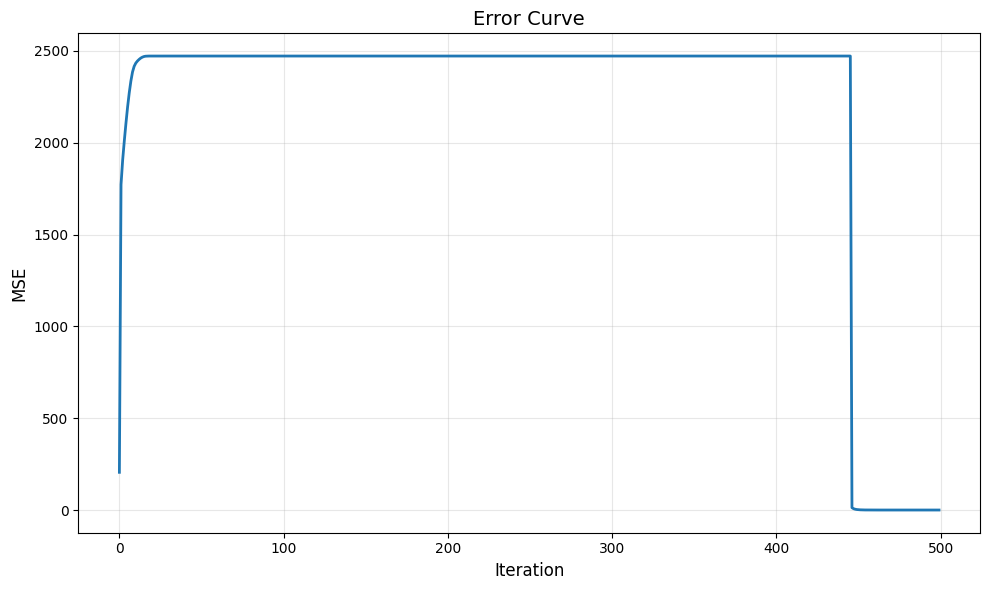


误差收敛情况:
  初始误差: 205.368713
  最终误差: 0.000026
  误差降低: 100.00%

相关性分析...
提取 A_recovered 第 28 行（索引 27）
最大相关位置索引: 28 (MATLAB索引)
最大相关值: 71.6308835897
✓ 成功！恢复的第 28 行与真实矩阵的第 28 行相关性最强


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from typing import Tuple, Optional

def tikinv(x: np.ndarray) -> np.ndarray:
    """简单的伪逆实现"""
    return np.linalg.pinv(x)

def GGS21_tm(y: np.ndarray, x: np.ndarray, opts: dict) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray]]:
    """
    Gerchberg-Saxton 2-1 algorithm to retrieve complex TM.
    The forward model is y = abs(A*x), from y and x, it returns the estimate of A

    Reference:
    Huang, G., et al. (2020). "Generalizing the Gerchberg–Saxton algorithm for
    retrieving complex optical transmission matrices." Photonics Research 9(1).

    Parameters:
    -----------
    y : np.ndarray
        Measured amplitude data, shape (m, p)
    x : np.ndarray
        Input patterns, shape (n, p)
    opts : dict
        Options dictionary with keys:
        - iters: number of iterations
        - nWorker: number of parallel workers (for GPU)
        - useGPU: whether to use GPU (not implemented in this version)
        - ratio: ratio for switching from GS-2 to GS-1 (default: 0.89)

    Returns:
    --------
    A_pr : np.ndarray
        Recovered transmission matrix, shape (m, n)
    ts : np.ndarray
        Time spent per iteration
    errCurve_all : np.ndarray or None
        Average error curve across all measurements
    """
    save_err = True  # Always save error for now

    m, p = y.shape
    n, _ = x.shape

    # Initialization
    y = y.T  # Shape: (p, m)
    iters = opts['iters']
    num_worker = opts.get('nWorker', 1)
    use_gpu = opts.get('useGPU', False)
    ratio = opts.get('ratio', 0.89)

    if use_gpu:
        print("Warning: GPU support not implemented in this Python version. Using CPU.")

    x = x.T.astype(np.complex64)  # Shape: (p, n)
    xinv = tikinv(x)  # Shape: (n, p)

    # Define matrix multiplication functions
    Xfun = lambda t: x @ t
    Xinvfun = lambda t: xinv @ t

    # Initialize A_pr with random complex numbers
    A_pr = (np.random.randn(n, m).astype(np.float32) +
            1j * np.random.randn(n, m).astype(np.float32)) / np.sqrt(2)

    # Phase initialization with random phases
    Y = y * np.exp(1j * 2 * np.pi * np.random.rand(p, m).astype(np.float32))

    # GGS2-1 algorithm
    err_curve = np.zeros((m, iters), dtype=np.float32)
    ts = np.zeros(iters, dtype=np.float32)

    t0 = time.time()

    for t in range(iters):
        # Update A estimate
        A_pr = Xinvfun(Y)

        # Forward propagation
        Y_iter = Xfun(A_pr)

        # Update Y based on GS-2 or GS-1
        if t < round(ratio * iters):  # GS-2
            Y = y**2 * np.exp(1j * np.angle(Y_iter))
        else:  # GS-1
            Y = y * np.exp(1j * np.angle(Y_iter))

        # Calculate error
        if save_err:
            err_curve[:, t] = np.linalg.norm(y - np.abs(Y_iter), axis=0)

        ts[t] = time.time() - t0

    # Calculate average error curve
    err_curve_all = np.mean(err_curve, axis=0) if save_err else None

    # Transpose back
    A_pr = A_pr.T

    # Normalization to std=1
    inf_ind = np.abs(A_pr) > 1e10
    if np.any(inf_ind):
        A_pr[inf_ind] = np.exp(1j * np.angle(A_pr[inf_ind]))

    std_val = np.std(A_pr)
    if std_val > 0:
        A_pr = A_pr / std_val

    return A_pr, ts, err_curve_all


# ==================== 示例使用代码 ====================

def main():
    """演示如何使用 GGS21_tm 函数"""

    # 1. 构造模拟数据
    print("=" * 60)
    print("构造模拟数据...")
    print("=" * 60)

    n = 64    # 输入自由度 (例如 SLM 的像素数)
    m = 81    # 输出自由度 (例如 摄像头检测到的像素数)
    p = 1000  # 测试模式的数量 (测量次数)

    # 模拟一个真实的传输矩阵 A_true
    np.random.seed(42)  # 为了结果可重复
    A_true = (np.random.randn(m, n) + 1j * np.random.randn(m, n)) / np.sqrt(2)

    # 随机生成输入模式 x (通常是复振幅)
    x = (np.random.randn(n, p) + 1j * np.random.randn(n, p)) / np.sqrt(2)

    # 计算输出的强度，并取其振幅 y (这是实际实验中能测得的数据)
    # 物理模型: y = abs(A * x)
    y = np.abs(A_true @ x)

    print(f"数据维度:")
    print(f"  A_true: {A_true.shape}")
    print(f"  x: {x.shape}")
    print(f"  y: {y.shape}")

    # 2. 配置 opts 字典
    print("\n" + "=" * 60)
    print("配置参数...")
    print("=" * 60)

    opts = {
        'iters': 500,      # 迭代次数
        'nWorker': 1,      # 并行块数
        'useGPU': False,   # 是否使用 GPU
        'ratio': 0.89      # GGS2-1 算法中 GS2 与 GS1 切换的比例阈值
    }

    print(f"迭代次数: {opts['iters']}")
    print(f"GS2/GS1 切换比例: {opts['ratio']}")

    # 3. 调用函数
    print("\n" + "=" * 60)
    print("开始恢复传输矩阵...")
    print("=" * 60)

    A_recovered, time_spent, err_curve = GGS21_tm(y, x, opts)

    # 4. 验证结果
    print("\n" + "=" * 60)
    print("验证结果...")
    print("=" * 60)

    # 检查恢复出的 A 与 真实的 A_true 的相关性
    A_recovered_norm = A_recovered.flatten() / np.linalg.norm(A_recovered.flatten())
    A_true_norm = A_true.flatten() / np.linalg.norm(A_true.flatten())
    fidelity = np.abs(A_recovered_norm - A_true_norm)

    print(f"恢复完成，总耗时: {np.sum(time_spent):.2f} 秒")
    print(f"保真度 (fidelity): {np.mean(fidelity):.10f}")

    # 5. 绘制误差收敛曲线
    if err_curve is not None:
        plt.figure(figsize=(10, 6))
        plt.plot(err_curve, linewidth=2)
        plt.title('Error Curve', fontsize=14)
        plt.xlabel('Iteration', fontsize=12)
        plt.ylabel('MSE', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"\n误差收敛情况:")
        print(f"  初始误差: {err_curve[0]:.6f}")
        print(f"  最终误差: {err_curve[-1]:.6f}")
        print(f"  误差降低: {(1 - err_curve[-1]/err_curve[0])*100:.2f}%")

    # 6. 额外分析：提取特定行并计算与真值的相关性
    print("\n" + "=" * 60)
    print("相关性分析...")
    print("=" * 60)

    # 提取第 32 行（Python索引从0开始，对应MATLAB的第32行是索引31）
    k = 27  # MATLAB的32对应Python的31
    # 取共轭转置，得到列向量
    row_k_conj = np.conj(A_recovered[k, :])

    # 与 A_true 相乘，结果为 A_true 每一行与 row_k_conj 的内积组成的向量
    res_vec = A_true @ row_k_conj

    # 取振幅并找最大值索引
    max_idx = np.argmax(np.abs(res_vec))
    max_val = np.abs(res_vec[max_idx])

    print(f"提取 A_recovered 第 {k+1} 行（索引 {k}）")
    print(f"最大相关位置索引: {max_idx + 1} (MATLAB索引)")
    print(f"最大相关值: {max_val:.10f}")

    if max_idx == k:
        print(f"✓ 成功！恢复的第 {k+1} 行与真实矩阵的第 {k+1} 行相关性最强")
    else:
        print(f"✗ 注意：恢复的第 {k+1} 行与真实矩阵的第 {max_idx+1} 行相关性最强")


if __name__ == "__main__":
    main()

PyTorch version: 2.9.0+cpu
CUDA available: False

构造模拟数据...
数据维度:
  A_true: torch.Size([81, 64])
  x: torch.Size([64, 1000])
  y: torch.Size([81, 1000])

配置参数...
迭代次数: 500
GS2/GS1 切换比例: 0.89
使用GPU: True

开始恢复传输矩阵...
Using device: cpu

验证结果...
恢复完成，总耗时: 1358.86 秒
保真度 (fidelity): 0.0157307889

误差曲线已保存为 'error_curve.png'


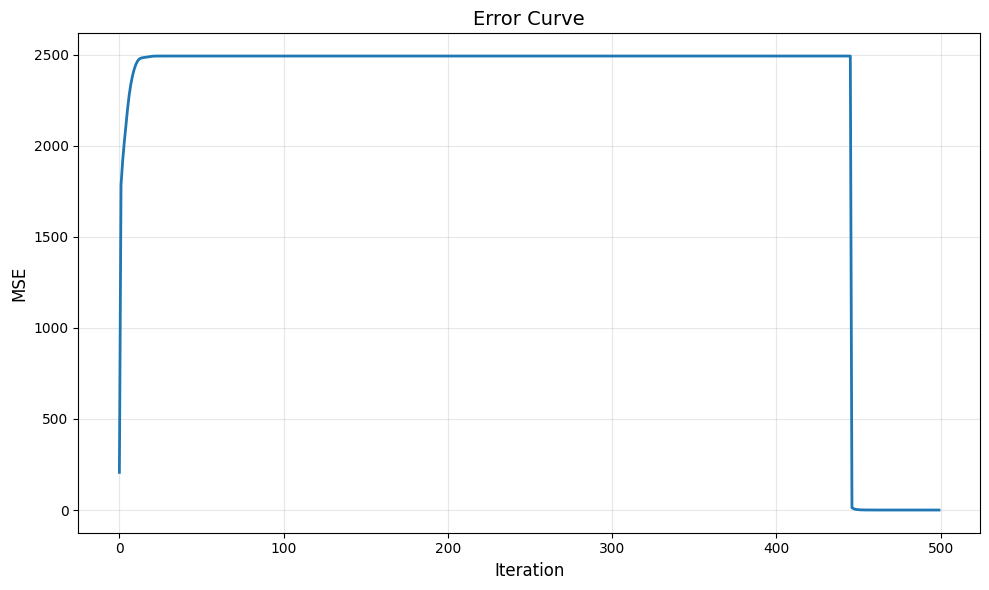


误差收敛情况:
  初始误差: 206.705505
  最终误差: 0.000366
  误差降低: 100.00%

相关性分析...
提取 A_recovered 第 24 行（索引 23）
最大相关位置索引: 24 (MATLAB索引)
最大相关值: 70.9119262695
✓ 成功！恢复的第 24 行与真实矩阵的第 24 行相关性最强


In [ ]:
import torch
import time
import matplotlib.pyplot as plt
from typing import Tuple, Optional

def tikinv(x: torch.Tensor) -> torch.Tensor:
    """简单的伪逆实现"""
    return torch.linalg.pinv(x)

def GGS21_tm(y: torch.Tensor, x: torch.Tensor, opts: dict) -> Tuple[torch.Tensor, torch.Tensor, Optional[torch.Tensor]]:
    """
    Gerchberg-Saxton 2-1 algorithm to retrieve complex TM (PyTorch version).
    The forward model is y = abs(A*x), from y and x, it returns the estimate of A

    Reference:
    Huang, G., et al. (2020). "Generalizing the Gerchberg–Saxton algorithm for
    retrieving complex optical transmission matrices." Photonics Research 9(1).

    Parameters:
    -----------
    y : torch.Tensor
        Measured amplitude data, shape (m, p)
    x : torch.Tensor
        Input patterns, shape (n, p)
    opts : dict
        Options dictionary with keys:
        - iters: number of iterations
        - nWorker: number of parallel workers (for GPU)
        - useGPU: whether to use GPU
        - ratio: ratio for switching from GS-2 to GS-1 (default: 0.89)
        - device: torch device (default: 'cuda' if available else 'cpu')

    Returns:
    --------
    A_pr : torch.Tensor
        Recovered transmission matrix, shape (m, n)
    ts : torch.Tensor
        Time spent per iteration
    errCurve_all : torch.Tensor or None
        Average error curve across all measurements
    """
    save_err = True  # Always save error for now

    m, p = y.shape
    n, _ = x.shape

    # Get device
    device = opts.get('device', 'cuda' if torch.cuda.is_available() else 'cpu')
    use_gpu = opts.get('useGPU', torch.cuda.is_available())

    if use_gpu and not torch.cuda.is_available():
        print("Warning: GPU requested but CUDA not available. Using CPU.")
        device = 'cpu'
    elif use_gpu:
        device = 'cuda'
    else:
        device = 'cpu'

    print(f"Using device: {device}")

    # Initialization
    iters = opts['iters']
    ratio = opts.get('ratio', 0.89)

    # Move data to device and ensure complex type
    y = y.T.to(device)  # Shape: (p, m)
    x = x.T.to(dtype=torch.complex64, device=device)  # Shape: (p, n)

    # Compute pseudo-inverse
    xinv = tikinv(x)  # Shape: (n, p)

    # Define matrix multiplication functions
    def Xfun(t):
        return x @ t

    def Xinvfun(t):
        return xinv @ t

    # Initialize A_pr with random complex numbers
    A_pr = (torch.randn(n, m, dtype=torch.float32, device=device) +
            1j * torch.randn(n, m, dtype=torch.float32, device=device)) / torch.sqrt(torch.tensor(2.0))
    A_pr = A_pr.to(torch.complex64)

    # Phase initialization with random phases
    random_phase = torch.rand(p, m, dtype=torch.float32, device=device) * 2 * torch.pi
    Y = y * torch.exp(1j * random_phase)

    # GGS2-1 algorithm
    err_curve = torch.zeros(m, iters, dtype=torch.float32, device=device)
    ts = torch.zeros(iters, dtype=torch.float32)

    t0 = time.time()

    for t in range(iters):
        # Update A estimate
        A_pr = Xinvfun(Y)

        # Forward propagation
        Y_iter = Xfun(A_pr)

        # Update Y based on GS-2 or GS-1
        if t < round(ratio * iters):  # GS-2
            Y = y**2 * torch.exp(1j * torch.angle(Y_iter))
        else:  # GS-1
            Y = y * torch.exp(1j * torch.angle(Y_iter))

        # Calculate error
        if save_err:
            err_curve[:, t] = torch.norm(y - torch.abs(Y_iter), dim=0)

        ts[t] = time.time() - t0

    # Calculate average error curve
    err_curve_all = torch.mean(err_curve, dim=0).cpu() if save_err else None

    # Transpose back
    A_pr = A_pr.T

    # Normalization to std=1
    inf_ind = torch.abs(A_pr) > 1e10
    if torch.any(inf_ind):
        A_pr[inf_ind] = torch.exp(1j * torch.angle(A_pr[inf_ind]))

    std_val = torch.std(A_pr)
    if std_val > 0:
        A_pr = A_pr / std_val

    return A_pr, ts, err_curve_all


# ==================== 示例使用代码 ====================

def main():
    """演示如何使用 GGS21_tm 函数 (PyTorch版本)"""

    # 设置设备
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA device: {torch.cuda.get_device_name(0)}")

    # 1. 构造模拟数据
    print("\n" + "=" * 60)
    print("构造模拟数据...")
    print("=" * 60)

    n = 64    # 输入自由度 (例如 SLM 的像素数)
    m = 81    # 输出自由度 (例如 摄像头检测到的像素数)
    p = 1000  # 测试模式的数量 (测量次数)

    # 模拟一个真实的传输矩阵 A_true
    torch.manual_seed(42)  # 为了结果可重复
    A_true = (torch.randn(m, n, dtype=torch.float32) +
              1j * torch.randn(m, n, dtype=torch.float32)) / torch.sqrt(torch.tensor(2.0))
    A_true = A_true.to(torch.complex64)

    # 随机生成输入模式 x (通常是复振幅)
    x = (torch.randn(n, p, dtype=torch.float32) +
         1j * torch.randn(n, p, dtype=torch.float32)) / torch.sqrt(torch.tensor(2.0))
    x = x.to(torch.complex64)

    # 计算输出的强度，并取其振幅 y (这是实际实验中能测得的数据)
    # 物理模型: y = abs(A * x)
    y = torch.abs(A_true @ x)

    print(f"数据维度:")
    print(f"  A_true: {A_true.shape}")
    print(f"  x: {x.shape}")
    print(f"  y: {y.shape}")

    # 2. 配置 opts 字典
    print("\n" + "=" * 60)
    print("配置参数...")
    print("=" * 60)

    opts = {
        'iters': 500,      # 迭代次数
        'nWorker': 1,      # 并行块数
        'useGPU': True,    # 是否使用 GPU
        'ratio': 0.89,     # GGS2-1 算法中 GS2 与 GS1 切换的比例阈值
        'device': device   # 设备
    }

    print(f"迭代次数: {opts['iters']}")
    print(f"GS2/GS1 切换比例: {opts['ratio']}")
    print(f"使用GPU: {opts['useGPU']}")

    # 3. 调用函数
    print("\n" + "=" * 60)
    print("开始恢复传输矩阵...")
    print("=" * 60)

    A_recovered, time_spent, err_curve = GGS21_tm(y, x, opts)

    # Move results back to CPU for analysis
    A_recovered = A_recovered.cpu()
    A_true = A_true.cpu()

    # 4. 验证结果
    print("\n" + "=" * 60)
    print("验证结果...")
    print("=" * 60)

    # 检查恢复出的 A 与 真实的 A_true 的相关性
    A_recovered_norm = A_recovered.flatten() / torch.norm(A_recovered.flatten())
    A_true_norm = A_true.flatten() / torch.norm(A_true.flatten())
    fidelity = torch.abs(A_recovered_norm - A_true_norm)

    print(f"恢复完成，总耗时: {torch.sum(time_spent).item():.2f} 秒")
    print(f"保真度 (fidelity): {torch.mean(fidelity).item():.10f}")

    # 5. 绘制误差收敛曲线
    if err_curve is not None:
        plt.figure(figsize=(10, 6))
        plt.plot(err_curve.numpy(), linewidth=2)
        plt.title('Error Curve', fontsize=14)
        plt.xlabel('Iteration', fontsize=12)
        plt.ylabel('MSE', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('error_curve.png', dpi=150, bbox_inches='tight')
        print("\n误差曲线已保存为 'error_curve.png'")
        plt.show()

        print(f"\n误差收敛情况:")
        print(f"  初始误差: {err_curve[0].item():.6f}")
        print(f"  最终误差: {err_curve[-1].item():.6f}")
        print(f"  误差降低: {(1 - err_curve[-1].item()/err_curve[0].item())*100:.2f}%")

    # 6. 额外分析：提取特定行并计算与真值的相关性
    print("\n" + "=" * 60)
    print("相关性分析...")
    print("=" * 60)

    # 提取第 32 行（Python索引从0开始，对应MATLAB的第32行是索引31）
    k = 23  # MATLAB的32对应Python的31
    # 取共轭转置，得到列向量
    row_k_conj = torch.conj(A_recovered[k, :])

    # 与 A_true 相乘，结果为 A_true 每一行与 row_k_conj 的内积组成的向量
    res_vec = A_true @ row_k_conj

    # 取振幅并找最大值索引
    max_idx = torch.argmax(torch.abs(res_vec)).item()
    max_val = torch.abs(res_vec[max_idx]).item()

    print(f"提取 A_recovered 第 {k+1} 行（索引 {k}）")
    print(f"最大相关位置索引: {max_idx + 1} (MATLAB索引)")
    print(f"最大相关值: {max_val:.10f}")

    if max_idx == k:
        print(f"✓ 成功！恢复的第 {k+1} 行与真实矩阵的第 {k+1} 行相关性最强")
    else:
        print(f"✗ 注意：恢复的第 {k+1} 行与真实矩阵的第 {max_idx+1} 行相关性最强")


if __name__ == "__main__":
    main()

Using device: cpu

[1/5] 构造模拟数据: N=128, M=256, P=1000

[2/5] 开始恢复传输矩阵...
Using device: cpu
恢复完成！耗时: 21.44s

[3/5] 基础指标:
  全局相关性 (Correlation): 0.0283248946

[4/5] 进行聚焦仿真 (Focusing Test)...
  目标像素索引: 128
  峰值背景比 (PBR): 131.60

[5/5] 绘制结果图...
结果图已保存为 'tm_focusing_test.png'


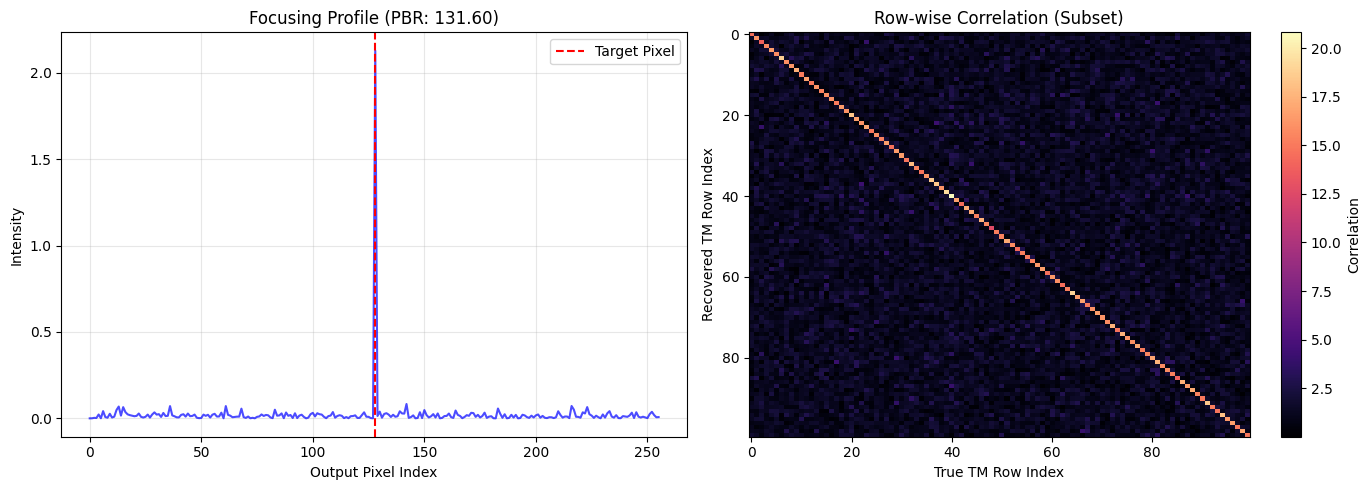

In [ ]:
import math
EPS = 1e-12
def run_focusing_test(A_true, A_rec, target_pixel: int):
    """
    进行聚焦仿真测试
    target_pixel: 目标聚焦像素索引
    """
    m, n = A_true.shape
    # 1. 计算相位共轭 (Phase Conjugation) 输入模式
    # 为了模拟 SLM 常见操作，我们取恢复矩阵对应行的共轭
    # 如果 SLM 只能相位调制，则取 exp(-j * angle(row))
    row_rec = A_rec[target_pixel, :]
    input_pattern = row_rec.conj()

    # 归一化输入能量
    input_pattern = input_pattern / (input_pattern.norm() + EPS)

    # 2. 通过真实的 TM 模拟物理输出
    output_complex = torch.matmul(A_true, input_pattern)
    output_intensity = torch.abs(output_complex)**2

    # 3. 计算 PBR (Peak-to-Background Ratio)
    peak_val = output_intensity[target_pixel].item()
    # 背景定义为除目标点以外的所有点的平均强度
    mask = torch.ones(m, device=A_true.device, dtype=torch.bool)
    mask[target_pixel] = False
    background_avg = torch.mean(output_intensity[mask]).item()

    pbr = peak_val / (background_avg + EPS)

    return output_intensity.cpu().numpy(), pbr
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(42)
    print(f"Using device: {device}")

    # 1. 配置参数
    n = 128    # 输入自由度 (SLM)
    m = 256    # 输出自由度 (Camera)
    p = 1000   # 测量模式数量 (通常建议 p > 2n-4n 之间)
    lam = 0.0  # TM 恢复通常不强制稀疏

    print(f"\n[1/5] 构造模拟数据: N={n}, M={m}, P={p}")
    A_true = (torch.randn(m, n, device=device) + 1j * torch.randn(m, n, device=device)) / math.sqrt(n)
    X = (torch.randn(n, p, device=device) + 1j * torch.randn(n, p, device=device)) / math.sqrt(n)
    Y = torch.abs(torch.matmul(A_true, X))

    # 2. FISTA 恢复
    print(f"\n[2/5] 开始恢复传输矩阵...")
    start_time = time.time()
    opts = {
        'iters': 500,      # 迭代次数
        'nWorker': 1,      # 并行块数
        'useGPU': True,    # 是否使用 GPU
        'ratio': 0.89,     # GGS2-1 算法中 GS2 与 GS1 切换的比例阈值
        'device': device   # 设备
    }
    A_rec, time_spent, err_curve = GGS21_tm(Y, X, opts)
    print(f"恢复完成！耗时: {time.time() - start_time:.2f}s")

    # 3. 基础精度验证
    A_rec_n = A_rec.flatten() / torch.norm(A_rec.flatten())
    A_true_n = A_true.flatten() / torch.norm(A_true.flatten())
    corr = torch.abs(torch.sum(A_rec_n.conj() * A_true_n)).item()
    print(f"\n[3/5] 基础指标:")
    print(f"  全局相关性 (Correlation): {corr:.10f}")

    # 4. 聚焦测试
    print(f"\n[4/5] 进行聚焦仿真 (Focusing Test)...")
    target_idx = m // 2 # 选取中间一个点作为目标点
    intensity_profile, pbr = run_focusing_test(A_true, A_rec, target_idx)
    print(f"  目标像素索引: {target_idx}")
    print(f"  峰值背景比 (PBR): {pbr:.2f}")
    iters = 500
    # 5. 可视化
    print(f"\n[5/5] 绘制结果图...")
    plt.figure(figsize=(14, 5))

    # 子图1: 聚焦分布
    plt.subplot(1, 2, 1)
    plt.plot(intensity_profile, color='blue', alpha=0.7)
    plt.axvline(x=target_idx, color='red', linestyle='--', label='Target Pixel')
    plt.title(f"Focusing Profile (PBR: {pbr:.2f})")
    plt.xlabel("Output Pixel Index")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图2: 局部相关性热图 (验证行列对应关系)
    plt.subplot(1, 2, 2)
    # 计算一个小范围的行相关性矩阵以加速显示
    subset_size = min(100, m)
    row_corr = torch.abs(torch.matmul(A_rec[:subset_size], A_true[:subset_size].conj().t()))
    plt.imshow(row_corr.cpu().numpy(), cmap='magma', aspect='auto')
    plt.colorbar(label='Correlation')
    plt.title("Row-wise Correlation (Subset)")
    plt.xlabel("True TM Row Index")
    plt.ylabel("Recovered TM Row Index")

    plt.tight_layout()
    plt.savefig('tm_focusing_test.png')
    print("结果图已保存为 'tm_focusing_test.png'")
    plt.show()

if __name__ == "__main__":
    main()